### Plot convergence graphs for all inversions

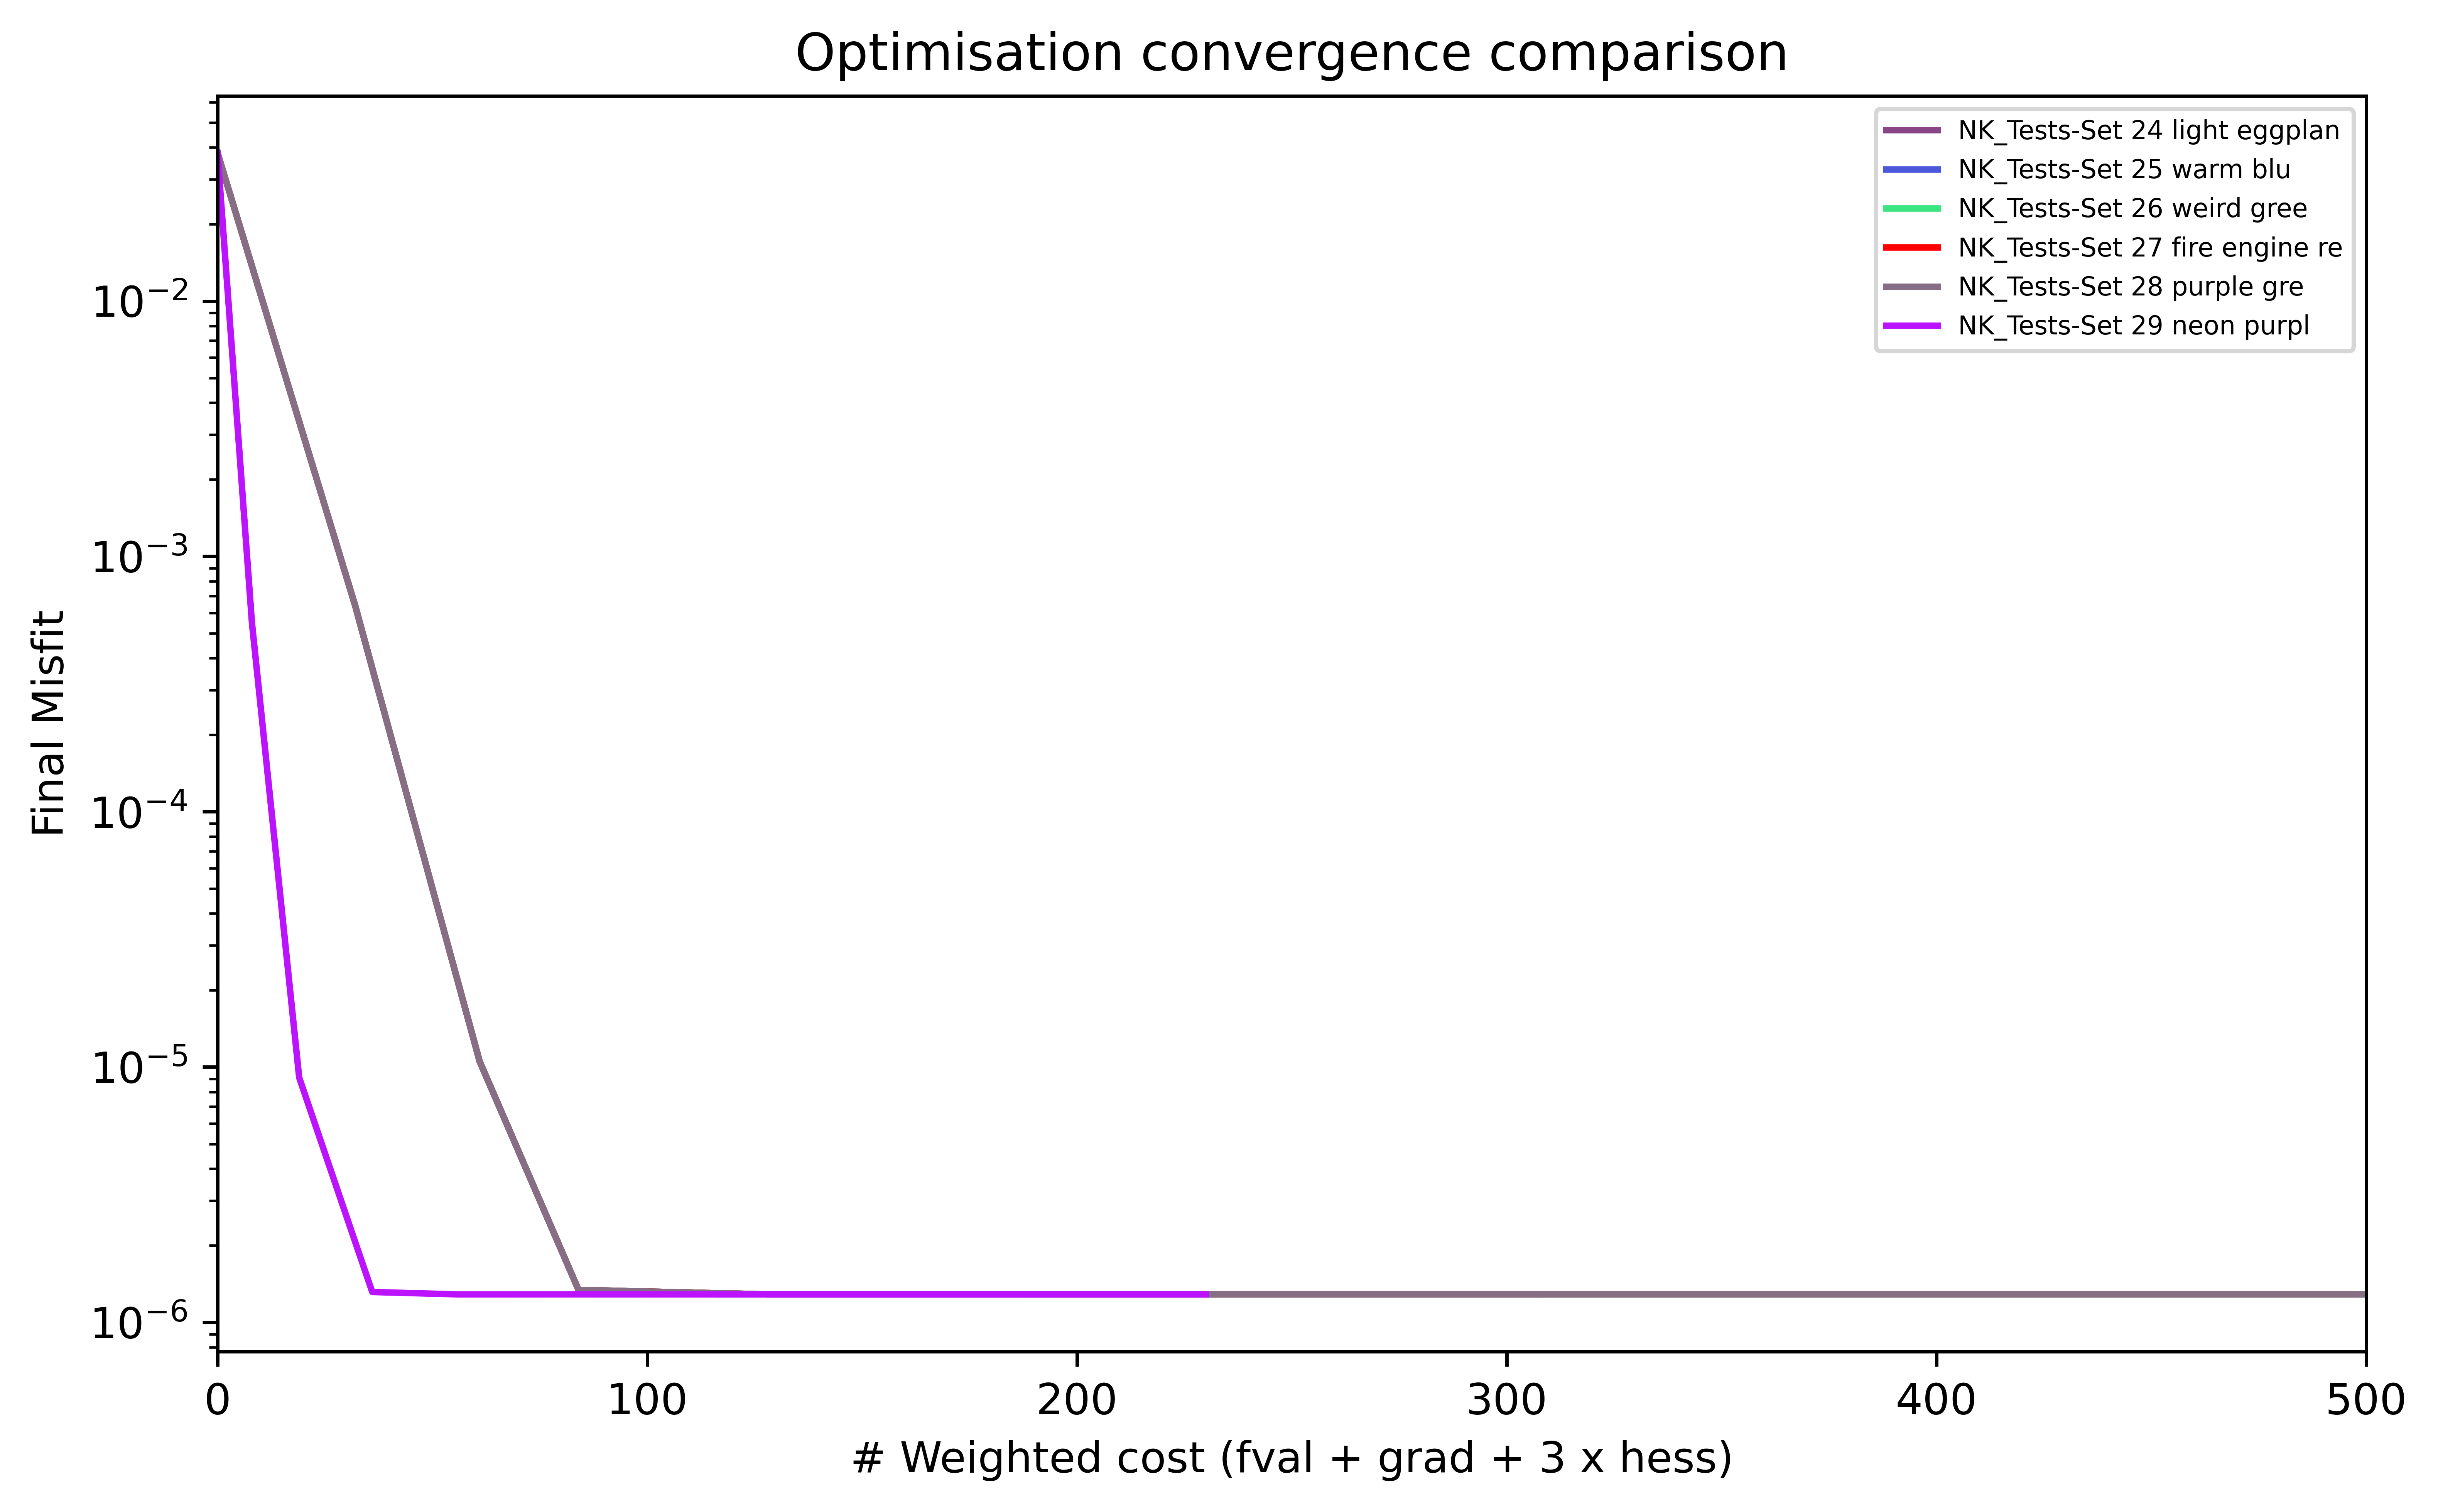

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import matplotlib.colors as mcolors

it = 0   #iteration count
# Change/Add to these parameters------------------------------------------------------------------------------------------------------------------------

# filenames = ['functional.txt', 'functional_LM_opt.txt', 'functional_NK_bounded.txt', 'functional_CL.txt', 'functional_KS.txt', 'functional_TSPG.txt', 'functional_LS_SD.txt', 'functional_LS_QNM.txt', 'functional_NK.txt', 'functional_TR_CP.txt', 'functional_TR_TCG.txt', 'functional_TR_DL.txt', 'functional_TR_DDL.txt']
# labels = ['Lin-More (red)', 'Lin-More optimal(yellow)', 'Newton-Krylov bounded (green)', 'Coleman Li (purple)', 'Kelley Sachs (black)', 'Trust region SPG (olive)', 'Line search Steepest Descent (gray)', 'Line search Quasi-Newton method (magenta)', 'Line Search Newton-Krylov unbounded (blue)', 'Trust region Cauchy point (lime)', 'Trust region Truncated CG (gold)', 'Trust region Dogleg (royal blue)', 'Trust region Double Dogleg (orange)']
# colors = ['red', 'yellow', 'green', 'purple', 'black', 'olive', 'gray', 'magenta', 'blue', 'lime', 'gold', 'royalblue', 'orange']
parameter_start = 24
parameter_end = 29
total_parameter_sets = parameter_end - parameter_start + 1
filenames = []
labels = []
for i in range(parameter_start, parameter_start+total_parameter_sets):
    # if i==5:
    #     continue
    # else:
    filenames.append('functional_NK_tests_'+ str(i)+'.txt')
    labels.append('NK_Tests-Set ' + str(i))

# filenames.append('functional_NK_tests_1.txt')
# labels.append('NK_Tests-Set 1')
# total_parameter_sets = total_parameter_sets+1

plot_type = 'Final Misfit'  # Define one of ['Functional values', 'Initial Misfit', 'Final Misfit']

plt.figure(figsize=(8,5), dpi=800)
for name in filenames:
    # We open the source file and get its lines
    in_filename = name
    with open(in_filename, 'r') as inp:
        lines = inp.readlines()

    total_hessians = []
    total_hessians.append(0)
    hessian_time_avg = []
    hessian_time_avg.append(0)
    total_func = []
    total_func.append(0)
    func_time_avg = []
    func_time_avg.append(0)
    total_grad = []
    total_grad.append(0)
    grad_time_avg = []
    grad_time_avg.append(0)
    func_values = []
    initial_misfits = []
    final_misfits = []
    func_values.append(float(lines[2].split()[2].replace(",", "")))
    initial_misfits.append(float(lines[2].split()[5].replace(",", "")))
    final_misfits.append(float(lines[2].split()[8].replace(",", "")))
    
    iteration_count = 1
    if 3*iteration_count+1 < len(lines):
        while 3*iteration_count+1 < len(lines):
            total_hessians.append(int(lines[3*iteration_count+1].split()[2].replace(",", "")))
            hessian_time_avg.append(float(lines[3*iteration_count+1].split()[6].replace(";", "")))
            total_func.append(int(lines[3*iteration_count+1].split()[9].replace(",", "")))
            func_time_avg.append(float(lines[3*iteration_count+1].split()[13].replace(";", "")))
            total_grad.append(int(lines[3*iteration_count+1].split()[16].replace(",", "")))
            grad_time_avg.append(float(lines[3*iteration_count+1].split()[20]))
            func_values.append(float(lines[3*iteration_count+2].split()[2].replace(",", "")))
            initial_misfits.append(float(lines[3*iteration_count+2].split()[5].replace(",", "")))
            final_misfits.append(float(lines[3*iteration_count+2].split()[8].replace(",", "")))
            iteration_count = iteration_count + 1
        func_values[0] = func_values[1]
        
    else:
        print("Currently the inversion has not progressed to the first iteration.")
    # weighted_x_axis = np.array([x * y for x, y in zip(total_hessians, hessian_time_avg)]) + np.array([x * y for x, y in zip(total_func, func_time_avg)]) + np.array([x * y for x, y in zip(total_grad, grad_time_avg)])
    weighted_x_axis = np.array([i * 1 for i in total_func]) + np.array([i * 1 for i in total_grad]) + np.array([i * 3 for i in total_hessians])
    total_colors = len(list(mcolors.XKCD_COLORS))
    chosen_color = list(mcolors.XKCD_COLORS)[int(it*total_colors/total_parameter_sets)+5]
    if plot_type == 'Functional values':
        plt.plot(weighted_x_axis, func_values, color=chosen_color, label=labels[it]+ ' ' + chosen_color[5:-1])
    elif plot_type == 'Initial Misfit':
        plt.plot(weighted_x_axis, initial_misfits, color=chosen_color, label=labels[it]+ ' ' + chosen_color[5:-1])
    elif plot_type == 'Final Misfit':
        plt.plot(weighted_x_axis, final_misfits, color=chosen_color, label=labels[it]+ ' ' + chosen_color[5:-1])
    it = it+1

# maxii = max(maxi)
plt.xlabel("# Weighted cost (fval + grad + 3 x hess)")
plt.ylabel(plot_type)
plt.yscale("log")
# plt.xticks(range(0,100))
plt.xlim(0, 500)
plt.legend(loc=1, prop={'size': 6})
plt.title('Optimisation convergence comparison')
plt.tight_layout()



In [44]:
# import matplotlib.colors as mcolors
# print(list(mcolors.XKCD_COLORS))
# print(list(mcolors.XKCD_COLORS)[0])
# print(name)
# print(filenames)

['functional_NK_tests_8.txt', 'functional_NK_tests_9.txt', 'functional_NK_tests_10.txt', 'functional_NK_tests_11.txt', 'functional_NK_tests_12.txt']


In [48]:
# in_filename = 'functional_NK_tests_11.txt'
# with open(in_filename, 'r') as inp:
#     lines = inp.readlines()

# total_hessians = []
# total_hessians.append(0)
# hessian_time_avg = []
# hessian_time_avg.append(0)
# total_func = []
# total_func.append(0)
# func_time_avg = []
# func_time_avg.append(0)
# total_grad = []
# total_grad.append(0)
# grad_time_avg = []
# grad_time_avg.append(0)
# func_values = []
# initial_misfits = []
# final_misfits = []
# func_values.append(float(lines[2].split()[2].replace(",", "")))
# initial_misfits.append(float(lines[2].split()[5].replace(",", "")))
# final_misfits.append(float(lines[2].split()[8].replace(",", "")))

# iteration_count = 1
# if 3*iteration_count+1 < len(lines):
#     while 3*iteration_count+1 < len(lines):
#         total_hessians.append(int(lines[3*iteration_count+1].split()[2].replace(",", "")))
#         hessian_time_avg.append(float(lines[3*iteration_count+1].split()[6].replace(";", "")))
#         total_func.append(int(lines[3*iteration_count+1].split()[9].replace(",", "")))
#         func_time_avg.append(float(lines[3*iteration_count+1].split()[13].replace(";", "")))
#         total_grad.append(int(lines[3*iteration_count+1].split()[16].replace(",", "")))
#         grad_time_avg.append(float(lines[3*iteration_count+1].split()[20]))
#         func_values.append(float(lines[3*iteration_count+2].split()[2].replace(",", "")))
#         initial_misfits.append(float(lines[3*iteration_count+2].split()[5].replace(",", "")))
#         final_misfits.append(float(lines[3*iteration_count+2].split()[8].replace(",", "")))
#         iteration_count = iteration_count + 1
#     func_values[0] = func_values[1]
    
# else:
#     print("Currently the inversion has not progressed to the first iteration.")
# weighted_x_axis = np.array([i * 1 for i in total_func]) + np.array([i * 1 for i in total_grad]) + np.array([i * 3 for i in total_hessians])
# # total_colors = len(list(mcolors.XKCD_COLORS))
# # chosen_color = list(mcolors.XKCD_COLORS)[int(it*total_colors/total_parameter_sets)+5]
# print(total_hessians, total_grad, total_func, weighted_x_axis)
# # plt.plot(weighted_x_axis, func_values, color=chosen_color, label=labels[it]+ ' ' + chosen_color[5:-1])
# # plt.plot(weighted_x_axis, initial_misfits, color=chosen_color, label=labels[it]+ ' ' + chosen_color[5:-1])
# # plt.plot(weighted_x_axis, final_misfits)

[0, 10, 19, 26, 40, 62, 84, 106, 127, 148, 169] [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10] [0, 1, 2, 3, 4, 5, 6, 7, 9, 16, 26] [  0  32  61  84 128 196 264 332 398 469 543]


In [9]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import csv
# import matplotlib.colors as mcolors

# # Change these inputs  
# parameter_file = 'Parameter_List_Adjoint_tutorial_Set_4.csv'
# in_filename = 'output_adjoint_NK.csv'

# out_filename = 'final_'+ in_filename

# # We open the source file and get its lines
# with open(in_filename, 'r') as inp:
#     lines = inp.readlines()

# # We open the target file in write-mode
# with open(out_filename, 'w') as out:
#     # We go line by line writing in the target file
#     # if the original line does not include the
#     # strings 'py-board' or 'coffee'
#     for line in lines:
#         if not 'SNES' in line and not 'Linear' in line and not 'Lin-More' in line and not 'Optimization' in line and not 'iter' in line and not 'Processed' in line and not 'Terminal' in line and not '<class' in line and not 'Method' in line and not 'Line' in line:
#             if line:
#                 out.write(line)

# # Find iteration limits from parameter file
# iteration_limits = []
# initial_radius = []
# radius_growing_rate = []
# radius_shrinking_rate_negative_rho= []
# radius_shrinking_rate_positive_rho= []
# radius_shrinking_threshold = []
# radius_growing_threshold = []
# with open(parameter_file) as csv_file:
#     csv_reader = csv.reader(csv_file, delimiter=',')
#     line_count = 0
#     for row in csv_reader:
#         if row[0]:
#             if line_count == 0:
#                 line_count += 1
#             else:
#                 iteration_limits.append(int(row[1]))
#                 initial_radius.append(float(row[2]))
#                 radius_growing_rate.append(float(row[3]))
#                 radius_shrinking_rate_negative_rho.append(float(row[4]))
#                 radius_shrinking_rate_positive_rho.append(float(row[5]))
#                 radius_shrinking_threshold.append(float(row[6]))
#                 radius_growing_threshold.append(float(row[7]))

# # Get fvals and grads
# fval = []
# grad = []
# with open(out_filename) as csv_file:
#     csv_reader = csv.reader(csv_file, delimiter=',')
#     line_count = 0
#     for row in csv_reader:
#         if any(field.strip() for field in row):
#             line_count= line_count+1
#             column=0
#             for t in row[0].split():
#                 try:
#                     column = column + 1
#                     if column == 7:
#                         grad.append(float(t))
#                     elif column == 6:
#                         fval.append(float(t))
#                 except ValueError:
#                     pass
# fval_plus_grad = [sum(n) for n in zip(*[fval, grad])]
# # print(f'gradients: {grad} \n fvals: {fval} \n fval+grad: {fval_plus_grad}')     

In [10]:
# # Change these inputs
# parameter_set_name = 'Set 4'
# functional_set = './functionals/functional_Set_4_'

# list=[] # Create an empty list for storing the functional values
# list_no = len(iteration_limits) # Total parameter sets
# index = 0 # Index for storing fval+grad sequence
# x_values = [] # empty list for storing the fval+grad for corresponding functional values
# # Read functional values from files
# for i in range(list_no):
#     filename = functional_set+str(i+1)+'.txt'
#     # Open the file in read mode
#     with open(filename, 'r') as file: 
#         # Read lines from the file 
#         lines = file.readlines() 
#     # Convert the lines to numbers 
#     numbers = [float(line.strip()) for line in lines] 
#     list.append(numbers)
#     fval_plus_grad_values = fval_plus_grad[index:index + len(numbers)]
#     index = index + len(numbers)
#     x_values.append(fval_plus_grad_values)

# # Plot the list of functional values
# plt.figure(figsize=(8,4), dpi=800)
# colors = mcolors.XKCD_COLORS
# names = sorted(colors, key=lambda c: tuple(mcolors.rgb_to_hsv(mcolors.to_rgb(c))))
# step = int(len(names)/list_no)
# for i in range(list_no):
#     # plt.plot(list[i], label='Parameter Set: '+ str(i+1), color=(random.random(), random.random(), random.random()))
#     label = '#Iter=' + str (iteration_limits[i]) + ', ' + 'R=' + str (initial_radius[i]) + ', ' + 'Rg=' + str (radius_growing_rate[i]) + ', ' \
#     + 'Rs$(-\\rho)$=' + str (radius_shrinking_rate_negative_rho[i]) + ', ' + 'Rs$(+\\rho)$=' + str (radius_shrinking_rate_positive_rho[i]) + ', ' \
#     + 'Rs_thresh=' + str (radius_shrinking_threshold[i]) + ', ' + 'Rg_thresh=' + str (radius_growing_threshold[i])
#     plt.plot(x_values[i], list[i], label=label, color = colors[names[i*step]])
#     # plt.plot(x_values[i], list[i])
    
# plt.xlabel("#(fval+grad)")
# plt.ylabel("Reduced functional")
# plt.yscale("log")
# plt.xticks(range(0,20))
# plt.legend(loc=1, prop={'size': 6})
# plt.title('Optimisation convergence for ' + parameter_set_name)
# plt.tight_layout()